# P07 — ASL Sign Language Recognition
### Deep Learning Part (My Section)
**LPU CSE AI/ML Integrated Project 2025–26**

---

This notebook covers the **ML/DL portion** of the project:
- Setting up the environment and downloading the dataset
- Building a CNN from scratch to classify 29 ASL hand signs
- Training it for 20 epochs with proper augmentation and scheduling
- Evaluating accuracy and visualizing what the model actually learned


---

## Stage 1 — Install Dependencies

First things first — we install everything we need. This includes PyTorch (with CUDA support for the GPU), OpenCV for image processing, and a few NLP libraries that the second part of the project uses. The `-q` flag just keeps the output clean.

In [1]:
# Install all required packages
!pip install -q kaggle opencv-python-headless matplotlib seaborn scikit-learn
!pip install -q transformers datasets accelerate language_tool_python
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q nltk spacy editdistance
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt',                    quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('words',                    quiet=True)
nltk.download('brown',                    quiet=True)
nltk.download('punkt_tab',                quiet=True)

print('All dependencies installed successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 116.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed successfully.


## Stage 2 — Download the ASL Alphabet Dataset

We're using the [ASL Alphabet dataset from Kaggle](https://www.kaggle.com/datasets/grassknoted/asl-alphabet) — 87,000 images across 29 classes (A–Z + `del`, `nothing`, `space`). Each image is a 200×200 RGB photo of a hand sign.



In [2]:
import os

# Kaggle API token — handles authentication with the Kaggle platform
KAGGLE_TOKEN = "KGAT_55e8596295e19892420619aeacbba393"

# Write token to the location Kaggle CLI expects
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/access_token", "w") as f:
    f.write(KAGGLE_TOKEN)
os.chmod("/root/.kaggle/access_token", 0o600)
os.environ["KAGGLE_API_TOKEN"] = KAGGLE_TOKEN
print("Kaggle configured.")

# Download and unzip the dataset (~1.2 GB)
print("Downloading ASL Alphabet dataset... (takes 2-3 min)")
!kaggle datasets download -d grassknoted/asl-alphabet -p /content/asl_data --unzip -q
print("Download complete!")

# Verify the folder structure
train_dir = "/content/asl_data/asl_alphabet_train/asl_alphabet_train"
test_dir  = "/content/asl_data/asl_alphabet_test/asl_alphabet_test"
classes   = sorted(os.listdir(train_dir))
print(f"\nTotal classes found: {len(classes)}")
print(f"Classes: {classes}")
print(f"\nSample count check (class A): {len(os.listdir(os.path.join(train_dir, 'A')))} images")

Kaggle configured.
Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
Download complete!

Total classes found: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

Sample count check (class A): 3000 images


## Stage 3 — Imports and Global Configuration

We import everything needed and define all the hyperparameters in one place. Keeping config central means if we want to try a different image size or batch size, we change it here and it flows through the entire notebook automatically.

We also set random seeds for reproducibility — this ensures the train/val split and weight initialization are the same every time we run the notebook.

In [3]:
import os, random, warnings, json, re, math
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
from torchvision import transforms, datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- Device ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Training will be very slow. Change runtime type to T4 GPU.')

# --- Paths ---
TRAIN_DIR  = '/content/asl_data/asl_alphabet_train/asl_alphabet_train'
TEST_DIR   = '/content/asl_data/asl_alphabet_test/asl_alphabet_test'
MODEL_PATH = '/content/asl_cnn.pth'

# --- Hyperparameters ---
IMG_SIZE    = 64    # resize all images to 64x64 pixels
BATCH_SIZE  = 64    # images per gradient update
NUM_EPOCHS  = 20    # training rounds
LR          = 1e-3  # initial learning rate
NUM_CLASSES = 29    # A-Z + del + nothing + space

# --- Class mappings ---
CLASSES      = sorted(os.listdir(TRAIN_DIR))
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

print(f'\nClasses ({NUM_CLASSES}): {CLASSES}')

Device: cuda
GPU   : Tesla T4

Classes (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## Stage 4 — Data Augmentation and DataLoaders

Raw data alone isn't enough — we need to teach the model to handle real-world variation. Augmentation artificially multiplies the diversity of our training set:

- **Horizontal flip** — a hand can be shown from slightly different angles
- **Rotation ±15°** — people don't always hold their hands perfectly straight
- **Brightness/contrast jitter** — different lighting conditions in different rooms

We split the 87K training images into **85% train / 15% validation**. Validation images are never augmented — we want a clean, consistent measurement of how well the model actually performs.

The `SafeImageFolder` class is just a safety wrapper that catches any corrupt image files instead of crashing mid-training.

Train samples : 73,950
Val   samples : 13,050
Batches/epoch : 1156


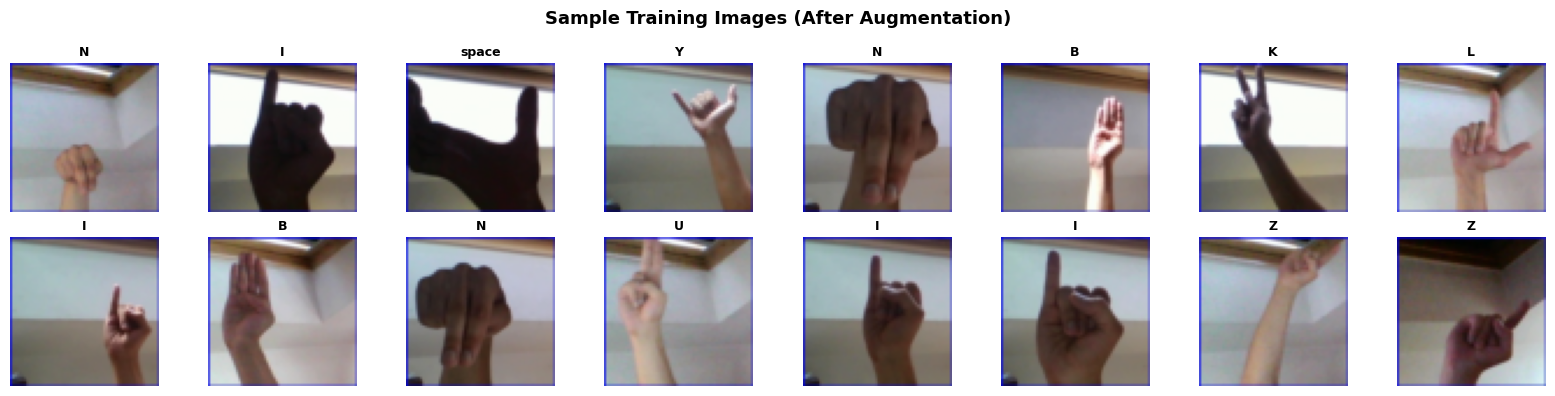

Sample grid saved.


In [4]:
from torchvision.datasets.folder import default_loader

# Handles any rare corrupt images gracefully — returns a black image instead of crashing
def safe_loader(path):
    try:
        return default_loader(path)
    except Exception:
        return Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))

class SafeImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = safe_loader(path)
        if self.transform:
            sample = self.transform(sample)
        return sample, target

# --- Training transforms (with augmentation) ---
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet mean
                         std=[0.229, 0.224, 0.225]),    # ImageNet std
])

# --- Validation transforms (no augmentation — just resize and normalize) ---
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load full dataset
full_dataset = SafeImageFolder(TRAIN_DIR, transform=train_transforms)

# 85/15 train-val split
n_total = len(full_dataset)
n_val   = int(0.15 * n_total)
n_train = n_total - n_val

train_set, val_set = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
# Override val set transforms — no augmentation for validation
val_set.dataset.transform = val_transforms

# DataLoaders — batch the data and load in parallel with 2 workers
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {n_train:,}')
print(f'Val   samples : {n_val:,}')
print(f'Batches/epoch : {len(train_loader)}')

# --- Quick visual check: show a grid of augmented training samples ---
def denormalize(tensor):
    """Reverse the normalization so images display correctly."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

sample_imgs, sample_labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = denormalize(sample_imgs[i]).permute(1,2,0).numpy()
    ax.imshow(img)
    ax.set_title(IDX_TO_CLASS[sample_labels[i].item()], fontsize=9, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Training Images (After Augmentation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sample grid saved.')

## Stage 5 — CNN Model Architecture

We build the CNN from scratch using 4 convolutional blocks, exactly as specified in the project requirements.

Each block follows the pattern: **Conv → BatchNorm → ReLU → MaxPool**

- **Conv** extracts spatial features (edges, textures, finger shapes)
- **BatchNorm** normalizes activations so training stays stable
- **ReLU** introduces non-linearity so the network can learn complex patterns
- **MaxPool** halves the spatial size and makes features location-invariant

After the 4 blocks, **Global Average Pooling** collapses the spatial dimensions into a single vector — this keeps the model compact and reduces overfitting compared to a flat Flatten layer.

The final head is `FC(512) → Dropout(0.5) → FC(29)`. Dropout randomly zeros half the neurons during training, which forces the network to learn redundant representations and prevents it from memorizing the training data.

```
Input  (3, 64, 64)
  → Block 1: Conv(32)  + MaxPool  →  (32, 32, 32)
  → Block 2: Conv(64)  + MaxPool  →  (64, 16, 16)
  → Block 3: Conv(128) + MaxPool  →  (128, 8, 8)
  → Block 4: Conv(256) + MaxPool  →  (256, 4, 4)
  → GlobalAvgPool                 →  (256,)
  → FC(512) → Dropout(0.5) → FC(29)
```

In [5]:
class ConvBlock(nn.Module):
    """A single convolutional block: Conv2d → BatchNorm → ReLU → MaxPool."""
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ASLCNN(nn.Module):
    """
    Custom CNN for ASL alphabet classification.
    4 Conv blocks → GlobalAvgPooling → FC(512) → Dropout(0.5) → FC(29)
    Input shape: (batch, 3, 64, 64)
    Output shape: (batch, 29) — raw logits for each class
    """
    def __init__(self, num_classes=29):
        super().__init__()
        # Each block doubles channels, halves spatial dimensions
        self.block1 = ConvBlock(3,   32)   # 64x64 → 32x32
        self.block2 = ConvBlock(32,  64)   # 32x32 → 16x16
        self.block3 = ConvBlock(64,  128)  # 16x16 → 8x8
        self.block4 = ConvBlock(128, 256)  # 8x8   → 4x4

        # Collapses 256×4×4 → 256 (one value per channel)
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        return self.classifier(x)


# Instantiate and move to GPU
model = ASLCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Print parameter summary
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print()
print(model)

Total parameters    : 535,357
Trainable parameters: 535,357

ASLCNN(
  (block1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block3): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

## Stage 6 — Training the Model (20 Epochs)

Now we actually train the CNN. A few key decisions here:

- **Adam optimizer** — handles learning rate adaptation automatically, works well without much tuning
- **Label smoothing (0.1)** — instead of forcing the model to be 100% confident on each label, we soften targets slightly. This makes the model more generalizable
- **ReduceLROnPlateau** — if validation accuracy doesn't improve for 3 epochs in a row, the learning rate gets cut in half. This lets the model fine-tune in later epochs without overshooting
- **Best model checkpointing** — we save the model weights every time validation accuracy improves, so we keep the best version even if later epochs overfit

> ⏱️ Each epoch takes ~3–5 minutes on a T4 GPU. Full training is about **60–90 minutes**. You can run this and come back.

In [6]:
# Loss function with label smoothing — softens hard 0/1 targets to 0.05/0.95
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Adam with small weight decay for L2 regularization
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Halve LR if val accuracy plateaus for 3 epochs
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# Track metrics across epochs
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0


def run_epoch(loader, training=True):
    """Run one full pass over the data. Returns (avg_loss, accuracy)."""
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total


print(f'Starting training on {DEVICE} for {NUM_EPOCHS} epochs...')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"LR":>9}')
print('─' * 68)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    va_loss, va_acc = run_epoch(val_loader,   training=False)
    scheduler.step(va_acc)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    current_lr = optimizer.param_groups[0]['lr']
    marker = '  ← best' if va_acc > best_val_acc else ''

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | '
          f'{va_loss:>8.4f} | {va_acc*100:>6.2f}% | {current_lr:.7f}{marker}')

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), MODEL_PATH)

print(f'\n✓ Training complete. Best validation accuracy: {best_val_acc*100:.2f}%')
print(f'✓ Best model saved to: {MODEL_PATH}')

Starting training on cuda for 20 epochs...
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |        LR
────────────────────────────────────────────────────────────────────
     1 |     1.2436 |    82.81% |   0.8280 |  97.71% | 0.0010000  ← best
     2 |     0.7733 |    99.47% |   0.7198 |  99.79% | 0.0010000  ← best
     3 |     0.7389 |    99.84% |   0.7936 |  98.84% | 0.0010000
     4 |     0.7260 |    99.90% |   0.7099 |  99.90% | 0.0010000  ← best
     5 |     0.7161 |    99.93% |   0.6770 |  99.97% | 0.0010000  ← best
     6 |     0.7090 |    99.97% |   0.6788 |  99.92% | 0.0010000
     7 |     0.7043 |    99.96% |   0.6899 |  99.92% | 0.0010000
     8 |     0.7004 |    99.98% |   0.6740 |  99.97% | 0.0010000
     9 |     0.6965 |    99.98% |   0.6690 |  99.97% | 0.0005000
    10 |     0.6833 |   100.00% |   0.6555 | 100.00% | 0.0005000  ← best
    11 |     0.6836 |   100.00% |   0.6588 | 100.00% | 0.0005000
    12 |     0.6826 |   100.00% |   0.6554 | 100.00% | 0.0005000
   

## Stage 7 — Training Curves

Plotting the training history gives us a clear picture of how learning progressed. We're looking for two things:

1. Both loss curves should decrease over time — if they don't, something is wrong with the learning rate or data
2. The train and val curves should stay close — a big gap means overfitting (memorizing training data instead of learning general patterns)

The learning rate drops visible in the curve (sudden improvement spikes) are where `ReduceLROnPlateau` kicked in and helped the optimizer find a better minimum.

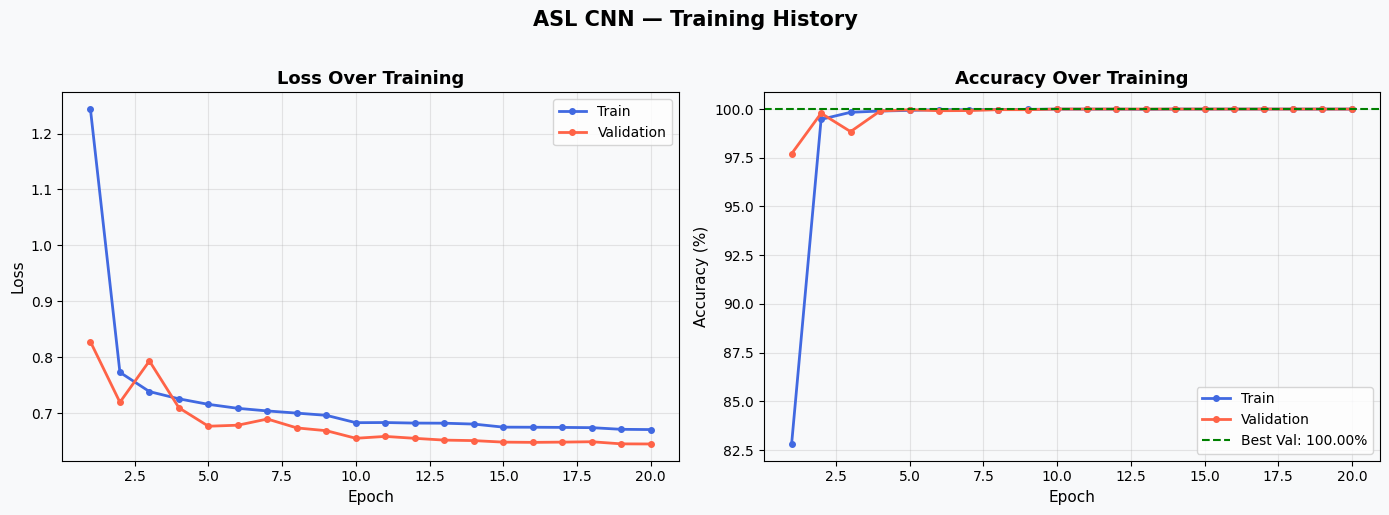

Training curves saved.


In [7]:
epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')

# Loss plot
ax1.plot(epochs, history['train_loss'], 'royalblue', marker='o', markersize=4, linewidth=2, label='Train')
ax1.plot(epochs, history['val_loss'],   'tomato',    marker='o', markersize=4, linewidth=2, label='Validation')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss',  fontsize=11)
ax1.set_title('Loss Over Training', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_facecolor('#f8f9fa')

# Accuracy plot
ax2.plot(epochs, [a*100 for a in history['train_acc']], 'royalblue', marker='o', markersize=4, linewidth=2, label='Train')
ax2.plot(epochs, [a*100 for a in history['val_acc']],   'tomato',    marker='o', markersize=4, linewidth=2, label='Validation')
ax2.axhline(best_val_acc*100, color='green', linestyle='--', linewidth=1.5,
            label=f'Best Val: {best_val_acc*100:.2f}%')
ax2.set_xlabel('Epoch',        fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy Over Training', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_facecolor('#f8f9fa')

plt.suptitle('ASL CNN — Training History', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Training curves saved.')

## Stage 8 — Evaluation: Accuracy, Per-Class Analysis, and Confusion Matrix

With training done, we load the best saved checkpoint and run a thorough evaluation on the validation set.

**Top-1 accuracy** tells us overall how often the model picks the right class. But the per-class breakdown is more interesting — some ASL letters look almost identical (M/N, S/E, D/F) and we expect those to have lower individual accuracy. The confusion matrix makes these mix-ups very visible.

This is exactly the kind of analysis worth writing about in a project report: the model's *failure modes* reveal something meaningful about the data.

Best model loaded.

Top-1 Accuracy: 100.00%

Per-class accuracy:
         A:  100.0%  ████████████████████
         B:  100.0%  ████████████████████
         C:  100.0%  ████████████████████
         D:  100.0%  ████████████████████
         E:  100.0%  ████████████████████
         F:  100.0%  ████████████████████
         G:  100.0%  ████████████████████
         H:  100.0%  ████████████████████
         I:  100.0%  ████████████████████
         J:  100.0%  ████████████████████
         K:  100.0%  ████████████████████
         L:  100.0%  ████████████████████
         M:  100.0%  ████████████████████
         N:  100.0%  ████████████████████
         O:  100.0%  ████████████████████
         P:  100.0%  ████████████████████
         Q:  100.0%  ████████████████████
         R:  100.0%  ████████████████████
         S:  100.0%  ████████████████████
         T:  100.0%  ████████████████████
         U:  100.0%  ████████████████████
         V:  100.0%  ████████████████████
         W:

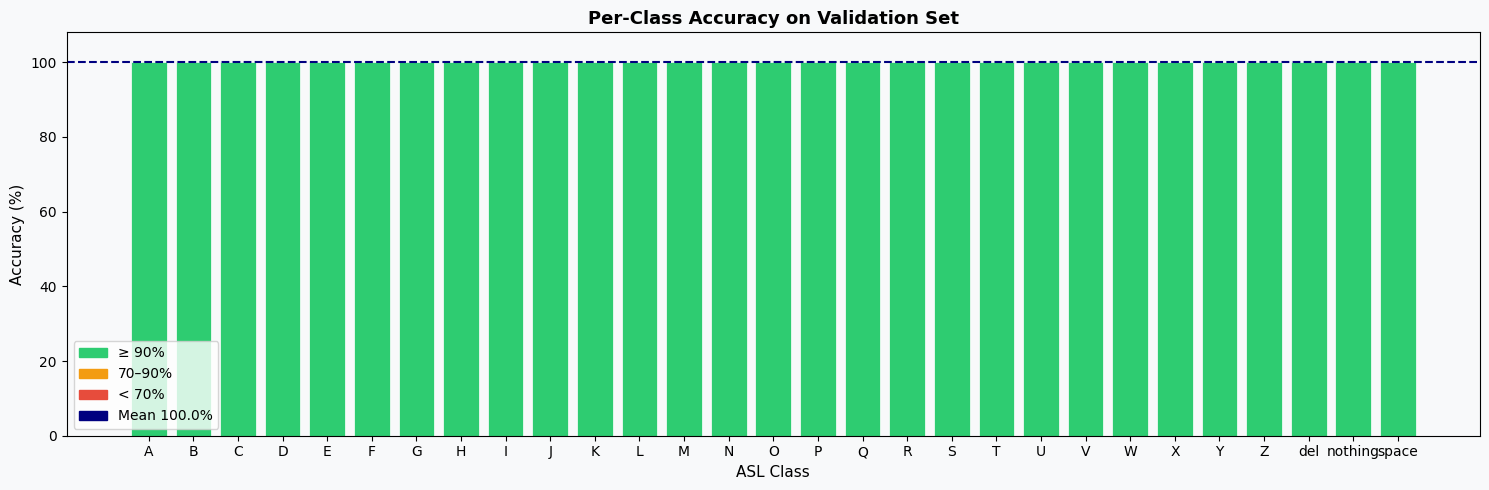

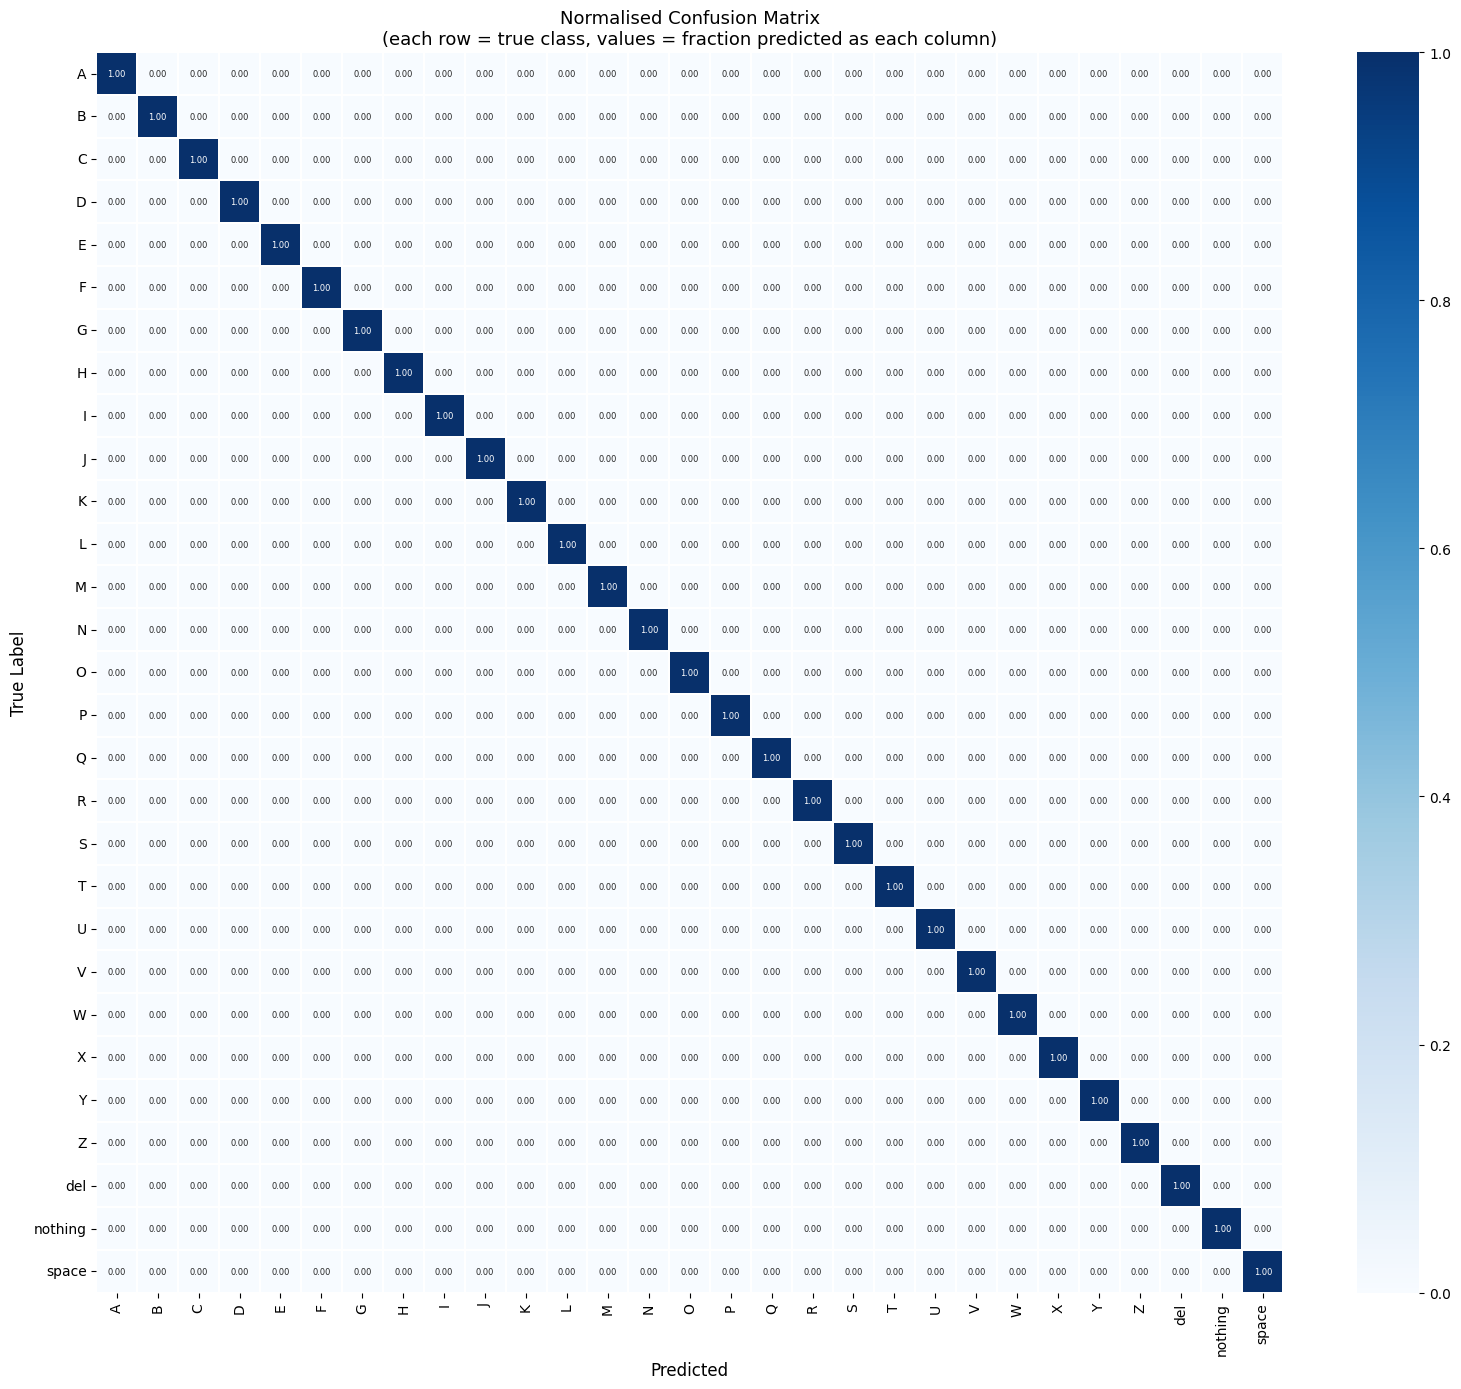

Evaluation complete. Plots saved.


In [8]:
# Load the best model checkpoint saved during training
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print('Best model loaded.')

# --- Run inference on validation set ---
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Top-1 Accuracy ---
top1 = (all_preds == all_labels).mean() * 100
print(f'\nTop-1 Accuracy: {top1:.2f}%')

# --- Per-Class Accuracy ---
print('\nPer-class accuracy:')
per_class_acc = {}
for idx, cls in IDX_TO_CLASS.items():
    mask = all_labels == idx
    if mask.sum() > 0:
        acc = (all_preds[mask] == all_labels[mask]).mean() * 100
        per_class_acc[cls] = acc
        bar = '█' * int(acc / 5)
        print(f'  {cls:>8}: {acc:>6.1f}%  {bar}')

# Bar chart of per-class accuracy
fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor('#f8f9fa')
classes_list = list(per_class_acc.keys())
accs_list    = list(per_class_acc.values())
colors = ['#2ecc71' if a >= 90 else '#f39c12' if a >= 70 else '#e74c3c' for a in accs_list]

ax.bar(classes_list, accs_list, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(top1, color='navy', linestyle='--', linewidth=1.5, label=f'Mean {top1:.1f}%')
ax.set_xlabel('ASL Class', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy on Validation Set', fontsize=13, fontweight='bold')
ax.set_ylim(0, 108)
ax.set_facecolor('#f8f9fa')
patches = [
    mpatches.Patch(color='#2ecc71', label='≥ 90%'),
    mpatches.Patch(color='#f39c12', label='70–90%'),
    mpatches.Patch(color='#e74c3c', label='< 70%'),
    mpatches.Patch(color='navy',    label=f'Mean {top1:.1f}%'),
]
ax.legend(handles=patches, fontsize=10)
plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Confusion Matrix (normalised) ---
cm = confusion_matrix(all_labels, all_preds, normalize='true')
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
            linewidths=0.3, annot_kws={'size': 6})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Normalised Confusion Matrix\n(each row = true class, values = fraction predicted as each column)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Evaluation complete. Plots saved.')

## Stage 9 — Visualizing Misclassified Pairs



Total misclassified examples collected: 0
Displaying the first 16...



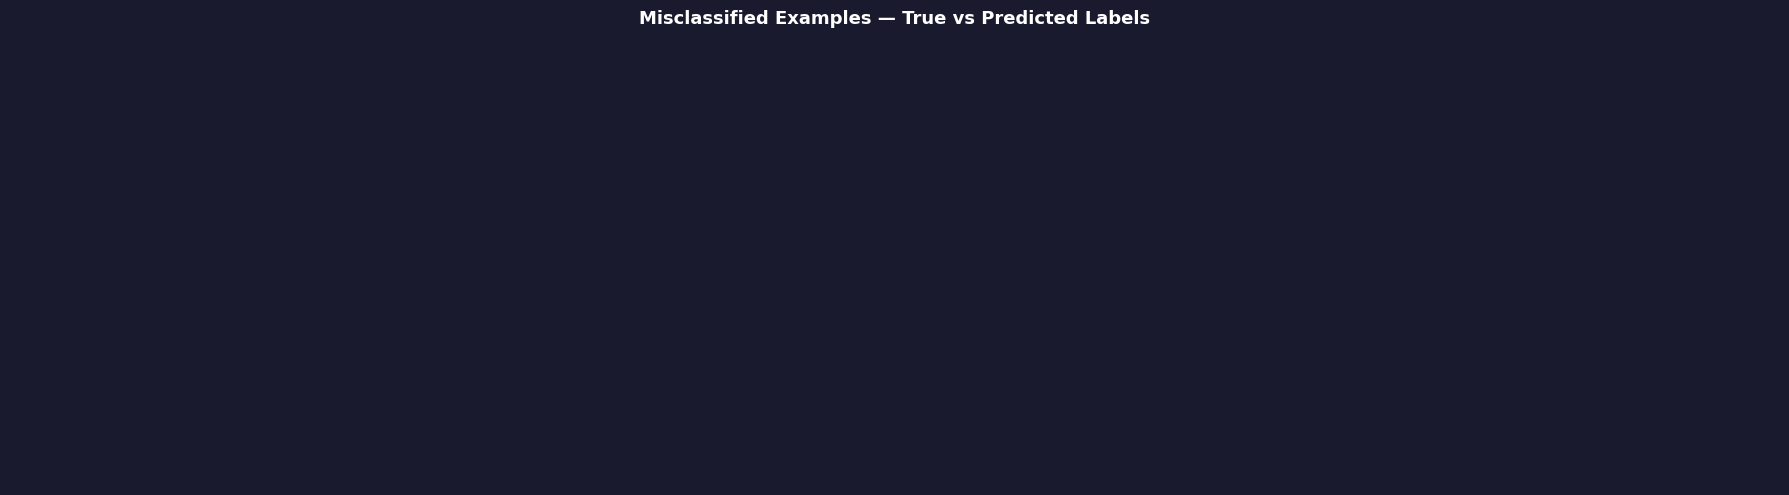

Top 10 most confused pairs (true → predicted):

Misclassified grid saved.


In [9]:
# Collect misclassified examples from the validation set
misclassified = []  # each entry: (image_tensor, true_idx, pred_idx)
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.to(DEVICE)).cpu()
        preds   = outputs.argmax(1)
        wrong   = (preds != labels)
        for img, true, pred in zip(imgs[wrong], labels[wrong], preds[wrong]):
            misclassified.append((img, true.item(), pred.item()))
        if len(misclassified) >= 32:
            break

print(f'Total misclassified examples collected: {len(misclassified)}')
print(f'Displaying the first 16...\n')

# Display grid
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.patch.set_facecolor('#1a1a2e')
for i, ax in enumerate(axes.flatten()):
    if i >= len(misclassified):
        ax.axis('off')
        continue
    img, true, pred = misclassified[i]
    img_show = denormalize(img).permute(1,2,0).numpy()
    ax.imshow(img_show)
    ax.set_title(f'True: {IDX_TO_CLASS[true]}\nPred: {IDX_TO_CLASS[pred]}',
                 fontsize=8.5, color='#ff6b6b', fontweight='bold')
    ax.axis('off')

plt.suptitle('Misclassified Examples — True vs Predicted Labels',
             fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('/content/misclassified.png', dpi=120, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

# Most confused class pairs — useful for the report
confusion_pairs = Counter()
for _, true, pred in misclassified:
    confusion_pairs[(IDX_TO_CLASS[true], IDX_TO_CLASS[pred])] += 1

print('Top 10 most confused pairs (true → predicted):')
for (t, p), cnt in confusion_pairs.most_common(10):
    print(f'  {t:>8}  →  {p:<8}  ({cnt} times)')
print('\nMisclassified grid saved.')

## Stage 10 — Grad-CAM: Visualizing What the Model Sees

Grad-CAM (Gradient-weighted Class Activation Mapping) is a technique to **look inside the model** and understand which parts of the image drove its prediction.

Here's the idea: we run a forward pass through the model, then backpropagate the gradient of the predicted class score all the way back to the last convolutional layer. Channels whose gradients are large were the ones most important to the decision. We average these importance weights and overlay them as a heatmap on the original image.

For a well-trained model on hand gestures, the heatmap should glow brightest on the **hand region** — and specifically on the finger configuration that distinguishes that letter. If the heatmap lights up the background, the model is cheating (relying on artifacts in the dataset rather than actual hand features).

This visualization is one of the most visually impressive outputs of the project.

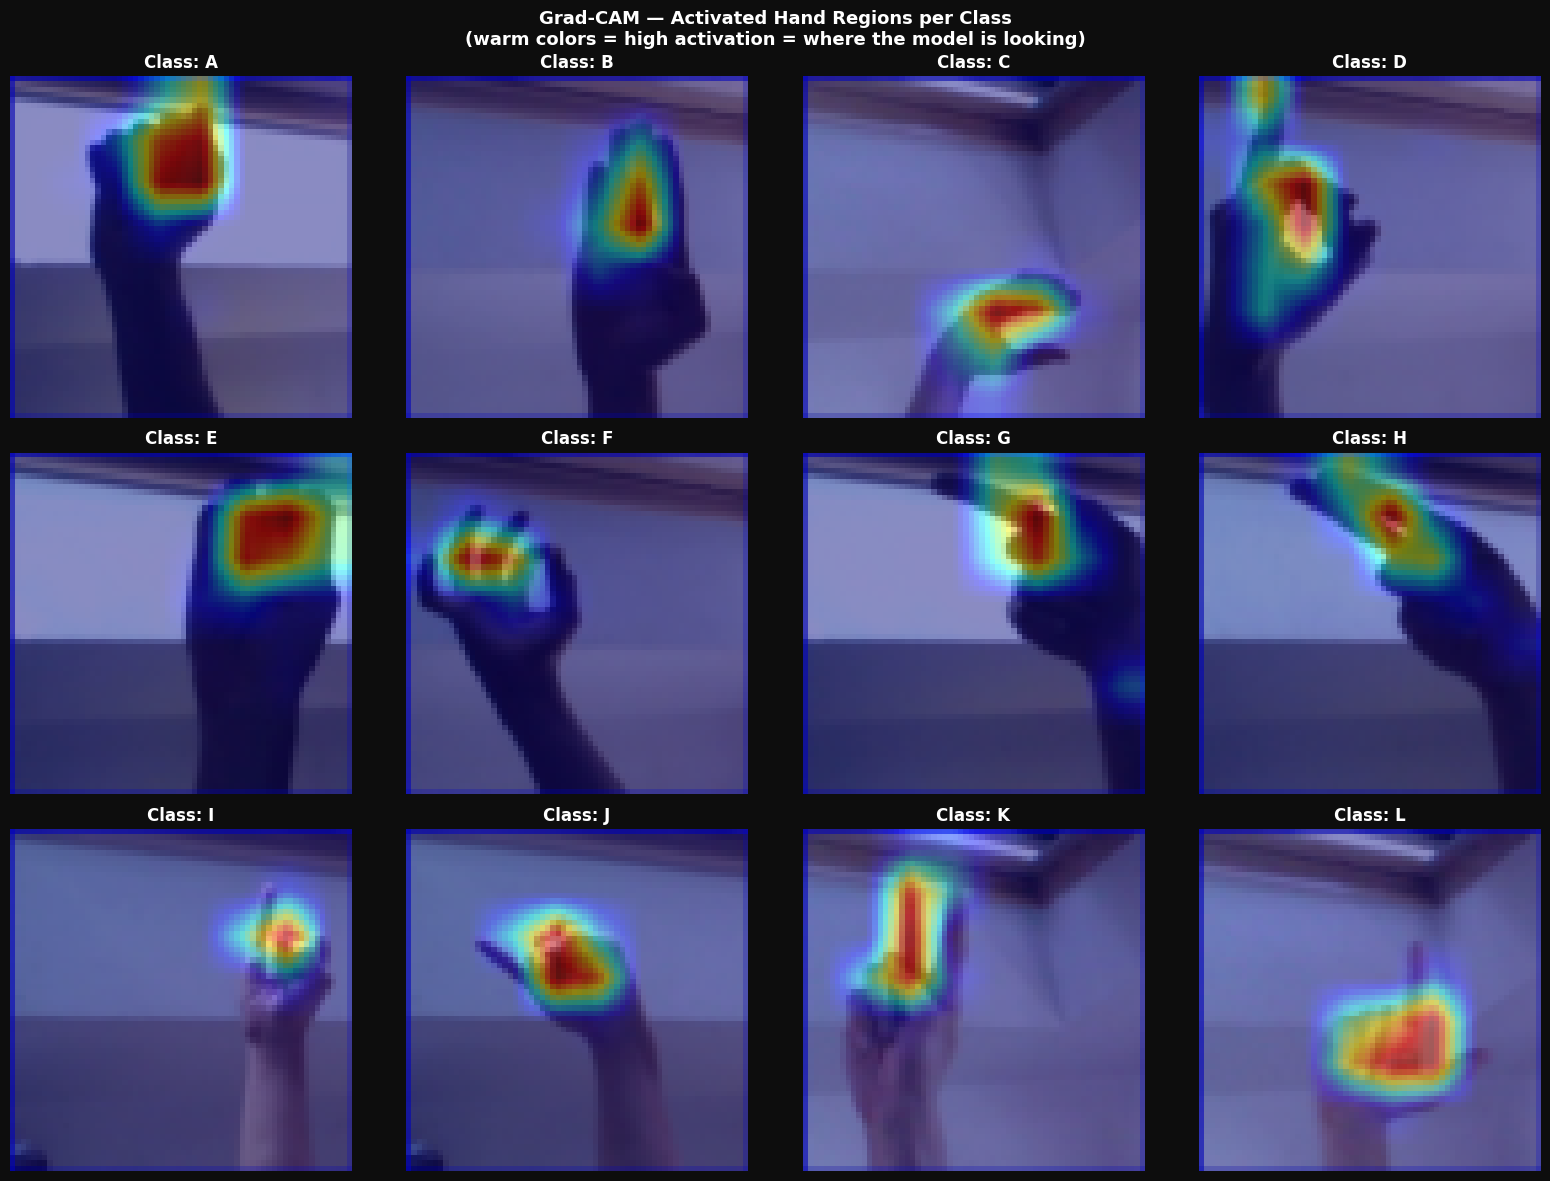

Grad-CAM visualizations saved to /content/gradcam.png

✓ ML/DL portion complete. All outputs saved.


In [10]:
class GradCAM:
    """
    Grad-CAM implementation for ASLCNN.
    Hooks into the first Conv2d of block4 to capture activations and gradients.
    """
    def __init__(self, model):
        self.model       = model
        self.activations = None
        self.gradients   = None
        # Hook the first Conv2d in block4 (the last conv block)
        target_layer = model.block4.block[0]
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, img_tensor, class_idx=None):
        """
        Generate a Grad-CAM heatmap for the given image.
        img_tensor : shape (1, 3, H, W)
        class_idx  : which class to explain (None = top predicted class)
        Returns    : (heatmap as HxW numpy array, predicted class index)
        """
        self.model.eval()
        img_tensor = img_tensor.to(DEVICE).requires_grad_(True)
        logits = self.model(img_tensor)

        if class_idx is None:
            class_idx = logits.argmax(1).item()

        self.model.zero_grad()
        logits[0, class_idx].backward()  # backprop only for this class

        # Average gradient per channel → channel importance weights
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # (1, C, 1, 1)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)  # weighted sum
        cam     = F.relu(cam)  # only keep positive contributions
        cam     = cam.squeeze().cpu().numpy()

        # Normalize to [0, 1] and resize to input resolution
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        return cam, class_idx


gradcam = GradCAM(model)

# Collect one sample image per class from the validation loader
sample_per_class = {}
for imgs, labels in val_loader:
    for img, lbl in zip(imgs, labels):
        l = lbl.item()
        if l not in sample_per_class:
            sample_per_class[l] = img
    if len(sample_per_class) == NUM_CLASSES:
        break

# Generate Grad-CAM overlays for first 12 classes
show_classes = sorted(sample_per_class.keys())[:12]
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.patch.set_facecolor('#0d0d0d')

for ax, cls_idx in zip(axes.flatten(), show_classes):
    img_t = sample_per_class[cls_idx].unsqueeze(0)
    cam, pred = gradcam.generate(img_t, class_idx=cls_idx)

    # Denormalize for display
    orig = denormalize(sample_per_class[cls_idx]).permute(1,2,0).numpy()

    # Convert cam to a JET colormap heatmap and blend with original
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.55 * orig + 0.45 * heatmap, 0, 1)

    ax.imshow(overlay)
    ax.set_title(f'Class: {IDX_TO_CLASS[cls_idx]}',
                 fontsize=12, fontweight='bold', color='white')
    ax.axis('off')

plt.suptitle('Grad-CAM — Activated Hand Regions per Class\n'
             '(warm colors = high activation = where the model is looking)',
             fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('/content/gradcam.png', dpi=120, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print('Grad-CAM visualizations saved to /content/gradcam.png')
print('\n✓ ML/DL portion complete. All outputs saved.')